[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Clases/CopiaClase18.ipynb)

# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## De la física a las propiedades geométricas de las cónicas

In [1]:
!pip install -Uq pymcel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 55.2 MB/s eta 0:00:00


In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


El problema comienza siempre con 2 cuerpos que se atraen gravitacionalmente:

In [3]:
# Unidades canónicas
G = 1

m1 = 1
r1_vec_0 = np.array([0, 0, 0])
v1_vec_0 = np.array([0, 0, 0])

m2 = 1
r2_vec_0 = np.array([1, 0, 0])
v2_vec_0 = np.array([0.5, 1, 0])

La pregunta que se hace la persona es: ¿cuál es la trayectoria que siguen esas dos partículas con esas condiciones iniciales?

El que tiene solución es el problema relativo:

In [4]:
mu = G * (m1 + m2)
r_vec_0 = r1_vec_0 - r2_vec_0
r0 = np.linalg.norm(r_vec_0)

v_vec_0 = v1_vec_0 - v2_vec_0
v0 = np.linalg.norm(v_vec_0)

Calculemos las cuadraturas del problema (constantes del problema)

In [5]:
h_vec = np.cross(r_vec_0, v_vec_0)
h = np.sqrt(h_vec[0]**2 + h_vec[1]**2 + h_vec[2]**2)
# %timeit h = np.linalg.norm(h_vec)
# %timeit h = np.sqrt(h_vec[0]**2 + h_vec[1]**2 + h_vec[2]**2)
# %timeit h = np.sqrt(h_vec@h_vec)
# %timeit h = (h_vec@h_vec)**0.5
h_vec, h

(array([0., 0., 1.]), np.float64(1.0))

In [6]:
e_vec = np.cross(v_vec_0, h_vec)/mu - r_vec_0 / r0
e = (e_vec@e_vec)**0.5

e_vec, e

(array([0.5 , 0.25, 0.  ]), np.float64(0.5590169943749475))

In [7]:
epsilon = v0**2 / 2 - mu / r0
epsilon

np.float64(-1.375)

Verifiquemos la fórmula de e:

In [8]:
e = np.sqrt(1 + 2*epsilon*h**2 / mu**2)
e

np.float64(0.5590169943749475)

Cantidades geométricas derivadas:

In [9]:
p = h**2 / mu
q = p / (1 + e)
Q = p / (1 - e)

p, q, Q

(np.float64(0.5),
 np.float64(0.3207149131818564),
 np.float64(1.1338305413635983))

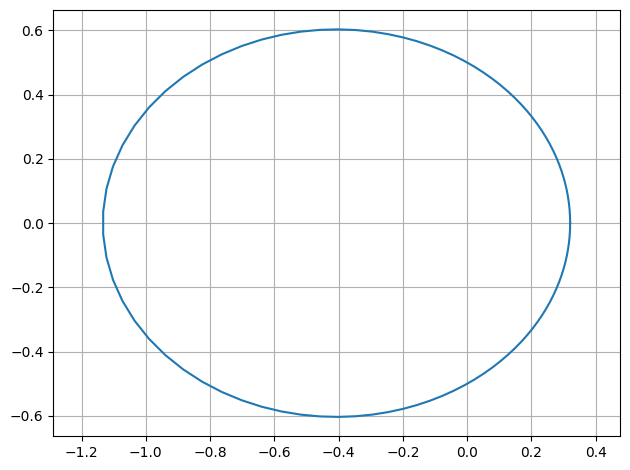

In [10]:
tetaers = np.linspace(0, 2*np.pi, 100)
rs = p / (1 + e*np.cos(tetaers))

xfs = rs * np.cos(tetaers)
yfs = rs * np.sin(tetaers)

plt.plot(xfs, yfs)
plt.axis('equal')
plt.grid()
plt.tight_layout()

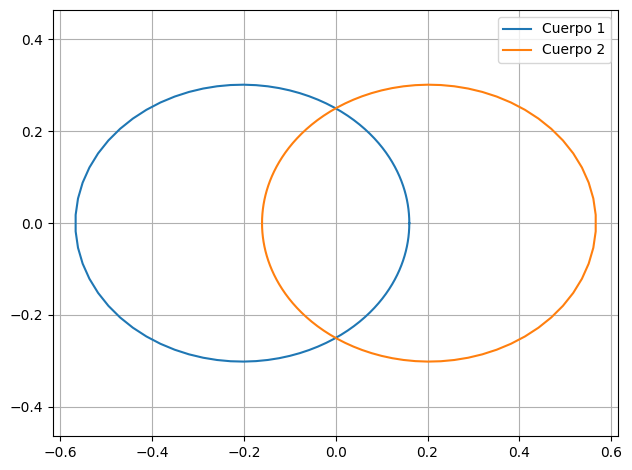

In [11]:
M = m1 + m2
rvecs = np.array([xfs, yfs]).T

r1vecs = m2/M * rvecs
r2vecs = - m1/M * rvecs

plt.plot(r1vecs[:,0], r1vecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')
plt.axis('equal')
plt.grid()
plt.legend()
plt.tight_layout()

Comparar con la teoría de N-cuerpos:

In [12]:
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]
ts = np.linspace(0, 10, 300)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

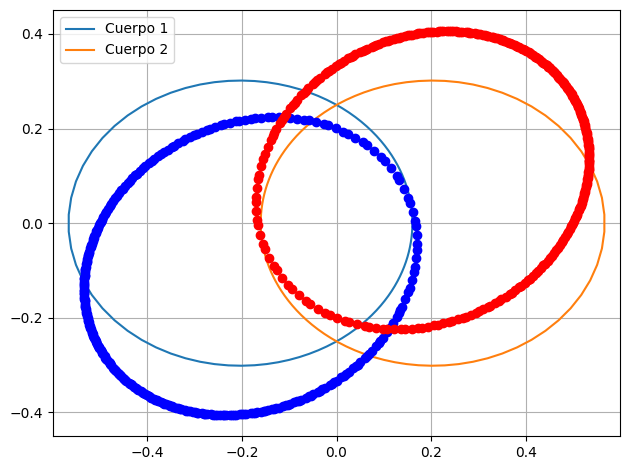

In [13]:
M = m1 + m2
rvecs = np.array([xfs, yfs]).T

r1vecs = m2/M * rvecs
r2vecs = - m1/M * rvecs

plt.plot(r1vecs[:,0], r1vecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')

plt.plot(rps[0,:,0], rps[0,:,1],'bo')
plt.plot(rps[1,:,0], rps[1,:,1],'ro')

plt.axis('equal')
plt.grid()
plt.legend()
plt.tight_layout()

## Cónica rotada

Para reconstruir la órbita primero tenemos que determinar el ángulo que forma el periapsis respecto del eje x (astronómico). Este ángulo lo llamamos **argumento del periapsis**:

$$
\cos\omega = \frac{\vec{e}\cdot \hat{a}_x}{e}
$$

In [14]:
w = np.arccos(e_vec@[1,0,0]/e)

rad = 180 / np.pi # Factor para convertir de radianes a grados
w*rad

np.float64(26.565051177077994)

Con este ángulo calculamos la matriz para pasar del sistema astronómico al sistema perifocal (propio de la cónica):

In [26]:
Rz = np.array([
    [np.cos(w), np.sin(w), 0],
    [-np.sin(w), np.cos(w), 0],
    [0, 0, 1]
])
Rz

array([[ 0.89442719,  0.4472136 ,  0.        ],
       [-0.4472136 ,  0.89442719,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

La matriz para pasar del sistema perifocal al sistema astronómico es la inversa:

In [27]:
Rz_inv = np.linalg.inv(Rz)
Rz_inv

array([[ 0.89442719, -0.4472136 ,  0.        ],
       [ 0.4472136 ,  0.89442719,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

Ahora para graficar usamos:

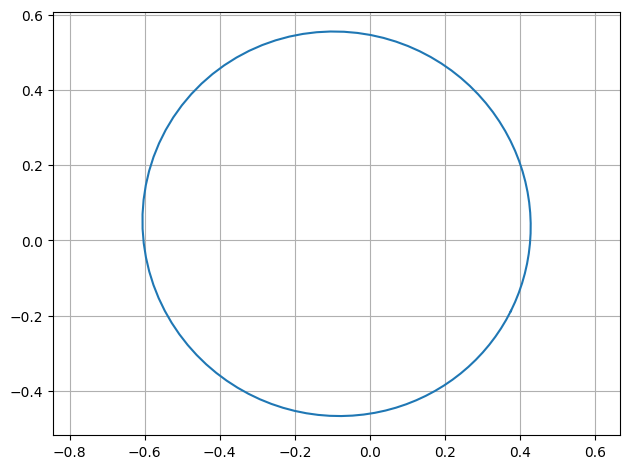

In [28]:
tetaers = np.linspace(0, 2*np.pi, 100)
rs = p / (1 + e*np.cos(tetaers))

xfs = rs * np.cos(tetaers)
yfs = rs * np.sin(tetaers)
zfs = np.zeros_like(xfs)

# Este comando hace la multiplicación matricial
rvecs = (Rz @ np.array([xfs, yfs, zfs])).T

plt.plot(rvecs[:,0], rvecs[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()

Y las órbitas quedaran:

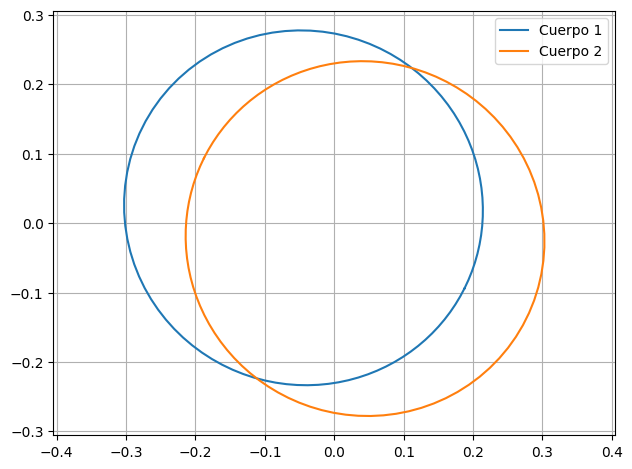

In [29]:
M = m1 + m2

r1vecs = m2/M * rvecs
r2vecs = - m1/M * rvecs

plt.plot(r1vecs[:,0], r1vecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')
plt.axis('equal')
plt.grid()
plt.legend()
plt.tight_layout()

Que se puede comparar con la solución numérica:

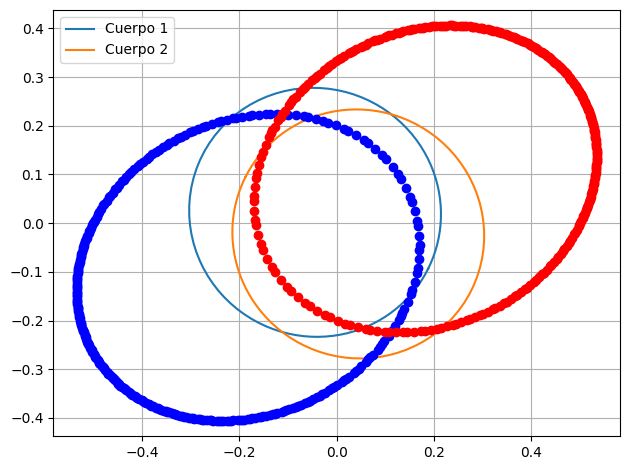

In [30]:
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]
ts = np.linspace(0, 10, 300)
rs, vs, rps, vps, cuadratura = pc.ncuerpos_solucion(sistema, ts)

plt.plot(r1vecs[:,0], r1vecs[:,1], label='Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label='Cuerpo 2')

plt.plot(rps[0,:,0], rps[0,:,1],'bo')
plt.plot(rps[1,:,0], rps[1,:,1],'ro')

plt.axis('equal')
plt.grid()
plt.legend()
plt.tight_layout()

## De elementos orbitales a la órbita en el espacio

In [31]:
deg = np.pi/180

In [32]:
e =	0.1911663355386932
a =	0.9223803173917017
q =	0.7460522521429133
i =	3.340958441017069 	* deg
node = 203.8996515621043 * deg
peri = 126.6728325163065 * deg

Matriz de rotación: pasa del sistema astronómico al sistema perifocal

In [33]:
import spiceypy as spy

In [41]:
Rz_omega = spy.rotate(peri, 3)
Rx_i = spy.rotate(i, 1)
Rz_Omega = spy.rotate(node, 3)
M_astro2perifocal = Rz_omega @ Rx_i @ Rz_Omega
# M_perifocal2astro = np.linalg.inv(M_astro2perifocal) #Metodo
# print(M_perifocal2astro)
M_perifocal2astro = M_astro2perifocal.T              #Metodo 2
print(M_perifocal2astro)

[[ 0.87042569  0.49173333 -0.02361039]
 [-0.4900758   0.87004992  0.05328075]
 [ 0.04674214 -0.03480605  0.99830041]]


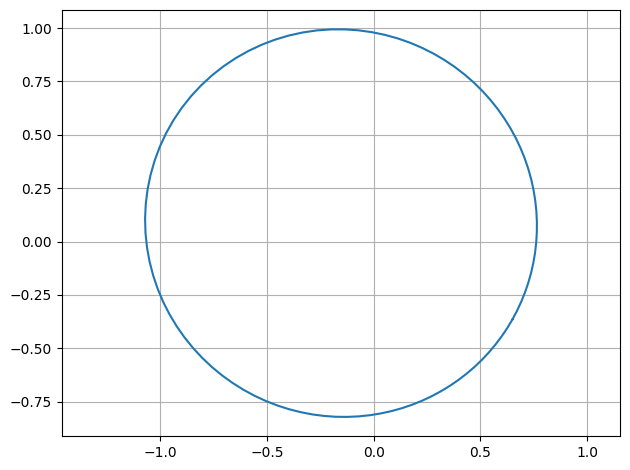

In [42]:
fs = np.linspace(0, 2*np.pi, 100)

p = q*(1+e)
rs = p / (1 + e*np.cos(fs))

xfs = rs * np.cos(fs)
yfs = rs * np.sin(fs)
zfs = np.zeros_like(xfs)

# Este comando hace la multiplicación matricial
rvecs = (M_perifocal2astro @ np.array([xfs, yfs, zfs])).T

plt.plot(rvecs[:,0], rvecs[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()